In [2]:
# ============================================================
# Step 1: Introduction
# ============================================================

# 1.1 Project Overview
print("""
╔══════════════════════════════════════════════════════════════╗
║   Exploratory Data Analysis (EDA) — Patient No-Show Dataset  ║
╚══════════════════════════════════════════════════════════════╝

1.1  Project: Patient Appointment No-Show Prediction

Dataset  : Medical Appointment No-Shows (cleaned_appointments_v3.csv)

Goal     : To understand patient behavior, appointment patterns,
           demographic factors, SMS communication impact, and
           waiting time effects before building machine learning
           models for no-show prediction.
""")

# 1.2 Dataset Feature Description
import pandas as pd

feature_desc = {
    "no_show"              : "Target — Whether patient missed appointment (1 = No-Show, 0 = Showed Up)",
    "age_group"            : "Patient age category (Child, Teen, Adult, Senior, Elderly)",
    "sms_received"         : "Whether patient received an SMS reminder (1 = Yes, 0 = No)",
    "appointment_weekday"  : "Day of the week the appointment was scheduled",
    "days_waiting"         : "Number of days between scheduling and the appointment date",
    "wait_bucket"          : "Binned waiting time category (0-7, 8-14, 15-30, 31-60, 60+)",
}

print("1.2  Dataset Feature Description\n")
print(pd.DataFrame(list(feature_desc.items()), columns=["Column Name", "Meaning"]).to_string(index=False))

# 1.3 Engineered Feature Description
print("\n\n1.3  Engineered Feature Description\n")
engineered_desc = {
    "wait_bucket" : "Days waiting grouped into 5 time-buckets for trend analysis",
}
print(pd.DataFrame(list(engineered_desc.items()), columns=["Engineered Feature", "Meaning"]).to_string(index=False))


╔══════════════════════════════════════════════════════════════╗
║   Exploratory Data Analysis (EDA) — Patient No-Show Dataset  ║
╚══════════════════════════════════════════════════════════════╝

1.1  Project: Patient Appointment No-Show Prediction

Dataset  : Medical Appointment No-Shows (cleaned_appointments_v3.csv)

Goal     : To understand patient behavior, appointment patterns,
           demographic factors, SMS communication impact, and
           waiting time effects before building machine learning
           models for no-show prediction.

1.2  Dataset Feature Description

        Column Name                                                                  Meaning
            no_show Target — Whether patient missed appointment (1 = No-Show, 0 = Showed Up)
          age_group               Patient age category (Child, Teen, Adult, Senior, Elderly)
       sms_received               Whether patient received an SMS reminder (1 = Yes, 0 = No)
appointment_weekday                  

In [7]:
# ============================================================
# Step 2: Data Understanding
# ============================================================

# 2.1 Library Import
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.offline import iplot
import plotly.io as pio
import warnings

warnings.filterwarnings('ignore')
sns.set_style("whitegrid")
pio.renderers.default = "notebook"
%matplotlib inline

print("✅ All libraries imported successfully.")

✅ All libraries imported successfully.


In [10]:
# 3.1 Missing Value Count
print("=== MISSING VALUE COUNT ===\n")
print(df.isnull().sum())

=== MISSING VALUE COUNT ===

gender                 0
age                    0
neighbourhood          0
scholarship            0
hipertension           0
diabetes               0
alcoholism             0
handcap                0
sms_received           0
no_show                0
days_waiting           0
appointment_weekday    0
scheduled_hour         0
same_day               0
age_group              0
is_weekend             0
long_wait              0
dtype: int64


In [11]:
# 3.2 Missing Value Percentage
print("=== MISSING VALUE PERCENTAGE ===\n")
missing_percent = (df.isnull().mean() * 100).sort_values(ascending=False)
print(missing_percent)

=== MISSING VALUE PERCENTAGE ===

gender                 0.0
age                    0.0
neighbourhood          0.0
scholarship            0.0
hipertension           0.0
diabetes               0.0
alcoholism             0.0
handcap                0.0
sms_received           0.0
no_show                0.0
days_waiting           0.0
appointment_weekday    0.0
scheduled_hour         0.0
same_day               0.0
age_group              0.0
is_weekend             0.0
long_wait              0.0
dtype: float64


In [12]:
# 3.3 Missing Value Ratio Table
total   = df.isnull().sum()
percent = (df.isnull().sum() / len(df)) * 100

missing_df = pd.concat([total, percent], axis=1, keys=['Total Missing', 'Missing Ratio (%)'])
missing_df = missing_df.sort_values(by='Missing Ratio (%)', ascending=False)

print("=== MISSING VALUE RATIO TABLE ===\n")
print(missing_df)

=== MISSING VALUE RATIO TABLE ===

                     Total Missing  Missing Ratio (%)
gender                           0                0.0
age                              0                0.0
neighbourhood                    0                0.0
scholarship                      0                0.0
hipertension                     0                0.0
diabetes                         0                0.0
alcoholism                       0                0.0
handcap                          0                0.0
sms_received                     0                0.0
no_show                          0                0.0
days_waiting                     0                0.0
appointment_weekday              0                0.0
scheduled_hour                   0                0.0
same_day                         0                0.0
age_group                        0                0.0
is_weekend                       0                0.0
long_wait                        0             

In [14]:
# 3.4 Missing Value Visualization
missing_percent = (df.isnull().mean() * 100).sort_values(ascending=False)
top_missing = missing_percent[missing_percent > 0]

if top_missing.empty:
    print("✅ No missing values found in the dataset — dataset is clean!")
else:
    # Color coding
    colors = []
    for val in top_missing:
        if val > 50:
            colors.append('red')
        elif val >= 20:
            colors.append('orange')
        else:
            colors.append('green')

    plt.figure(figsize=(10, 6))
    plt.barh(top_missing.index, top_missing.values, color=colors)
    plt.xlabel('Missing Percentage')
    plt.ylabel('Features')
    plt.title('Features with Missing Values\n(Red > 50%  |  Orange 20–50%  |  Green < 20%)')
    plt.gca().invert_yaxis()
    plt.grid(axis='x', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

✅ No missing values found in the dataset — dataset is clean!


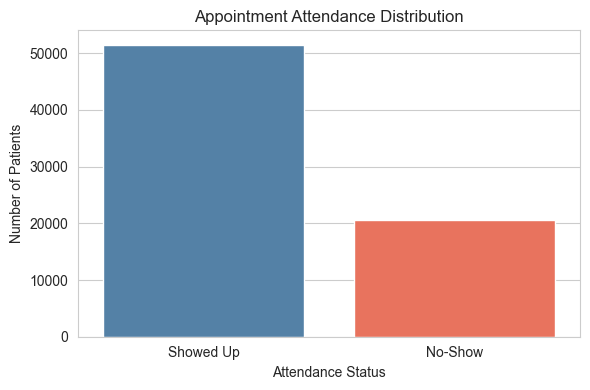

In [15]:
# 4.1 Target Variable Distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='no_show', data=df, palette=['steelblue', 'tomato'])
plt.xticks([0, 1], ['Showed Up', 'No-Show'])
plt.title("Appointment Attendance Distribution")
plt.xlabel("Attendance Status")
plt.ylabel("Number of Patients")
plt.tight_layout()
plt.show()

In [16]:
# 4.2 Class Imbalance Analysis
target_counts = df['no_show'].value_counts()

print("=== CLASS IMBALANCE ANALYSIS ===\n")
print(f"Showed Up  (0) : {target_counts[0]:,}")
print(f"No-Show    (1) : {target_counts[1]:,}")
print(f"Class Ratio    : {round(target_counts[0] / target_counts[1], 2)} : 1")
print(f"No-Show Rate   : {df['no_show'].mean() * 100:.2f}%")

=== CLASS IMBALANCE ANALYSIS ===

Showed Up  (0) : 51,437
No-Show    (1) : 20,522
Class Ratio    : 2.51 : 1
No-Show Rate   : 28.52%


In [17]:
# 5.1 Key Predictor Statistics by Target
key_cols = ['sms_received', 'days_waiting']

print("=== KEY PREDICTOR STATS BY NO-SHOW STATUS ===")

for col in key_cols:
    print(f"\n{col}:")
    stats = df.groupby('no_show')[col].agg(['mean', 'median', 'std'])
    stats.index = ['Showed Up', 'No-Show']
    print(stats.round(3))
    print(f"Missing: {df[col].isnull().mean() * 100:.1f}%")

=== KEY PREDICTOR STATS BY NO-SHOW STATUS ===

sms_received:
            mean  median    std
Showed Up  0.500     0.0  0.500
No-Show    0.477     0.0  0.499
Missing: 0.0%

days_waiting:
             mean  median     std
Showed Up  14.013     7.0  16.404
No-Show    16.218    12.0  16.614
Missing: 0.0%


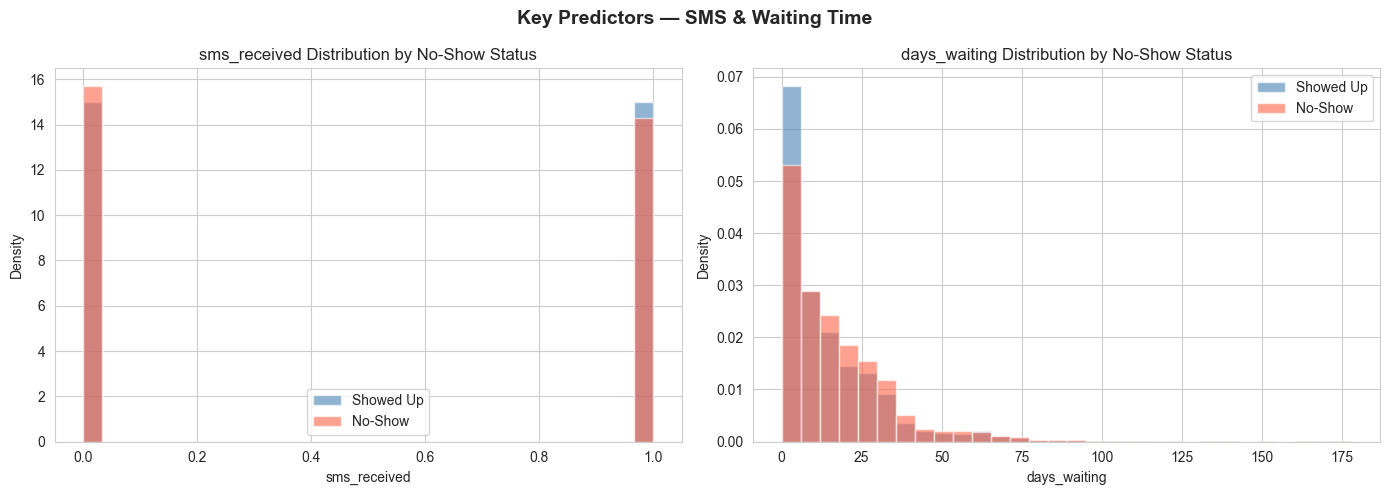

In [18]:
# 5.2 Distribution of Key Predictors by No-Show Status
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, col in enumerate(['sms_received', 'days_waiting']):
    ax = axes[i]
    for target, color, label in zip(
        [0, 1],
        ['steelblue', 'tomato'],
        ['Showed Up', 'No-Show']
    ):
        data = df[df['no_show'] == target][col].dropna()
        ax.hist(data, bins=30, alpha=0.6, color=color, label=label, density=True)
        ax.set_title(f'{col} Distribution by No-Show Status')
        ax.set_xlabel(col)
        ax.set_ylabel('Density')
        ax.legend()

plt.suptitle('Key Predictors — SMS & Waiting Time', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Combined Risk Score ROC-AUC: 0.554
Higher score = longer wait without SMS reminder = higher no-show risk.


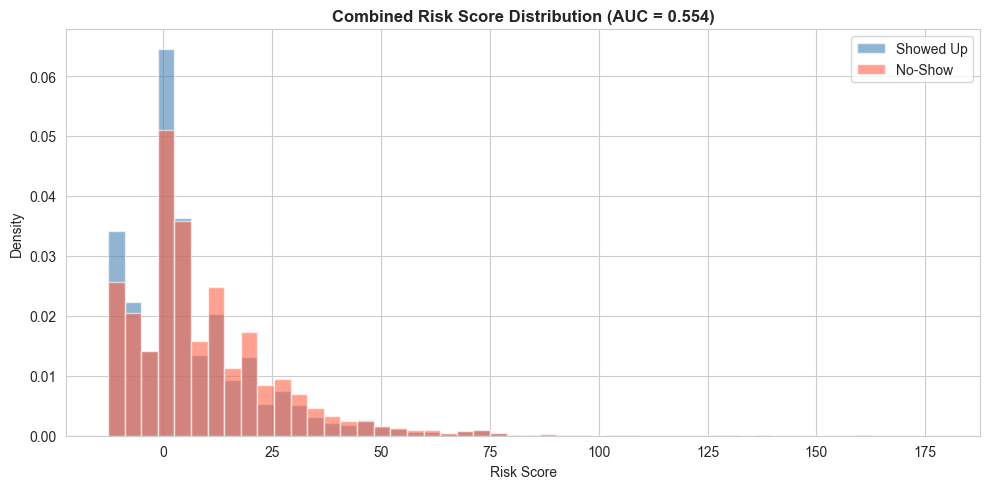

In [19]:
# 5.3 Combined Predictor Score (SMS Penalty + Wait Impact)
from sklearn.metrics import roc_auc_score

# Create a combined risk score: longer wait + no SMS = higher no-show risk
df['RISK_SCORE'] = df['days_waiting'] - (df['sms_received'] * df['days_waiting'].mean())

valid = df[['RISK_SCORE', 'no_show']].dropna()
auc = roc_auc_score(valid['no_show'], valid['RISK_SCORE'])

print(f"Combined Risk Score ROC-AUC: {auc:.3f}")
print("Higher score = longer wait without SMS reminder = higher no-show risk.")

# Visualization
plt.figure(figsize=(10, 5))
for target, color, label in zip([0, 1], ['steelblue', 'tomato'], ['Showed Up', 'No-Show']):
    data = df[df['no_show'] == target]['RISK_SCORE'].dropna()
    plt.hist(data, bins=50, alpha=0.6, density=True, color=color, label=label)

plt.title(f'Combined Risk Score Distribution (AUC = {auc:.3f})', fontweight='bold')
plt.xlabel('Risk Score')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.show()

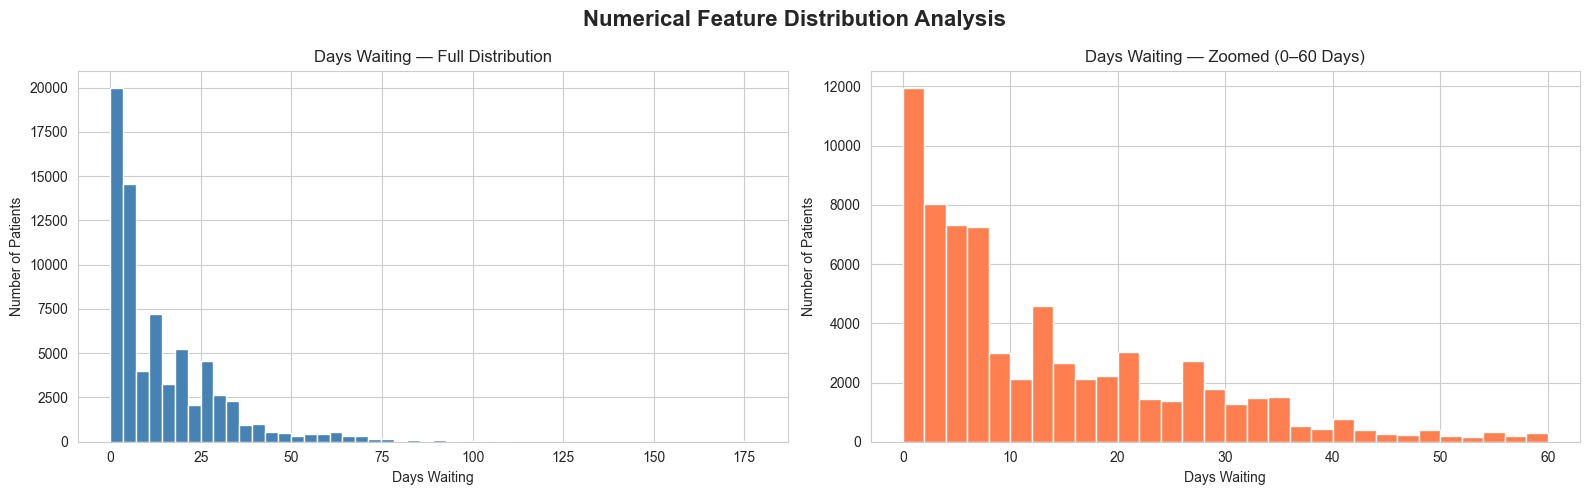

In [20]:
# 6.1 Numerical Feature Distributions
num_cols = ['days_waiting']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Numerical Feature Distribution Analysis', fontsize=16, fontweight='bold')

# Histogram with KDE — days_waiting
ax1 = axes[0]
df['days_waiting'].hist(bins=50, ax=ax1, color='steelblue', edgecolor='white')
ax1.set_title('Days Waiting — Full Distribution')
ax1.set_xlabel('Days Waiting')
ax1.set_ylabel('Number of Patients')

# Zoomed view (0–60 days, removing extreme outliers)
ax2 = axes[1]
df[df['days_waiting'] <= 60]['days_waiting'].hist(bins=30, ax=ax2, color='coral', edgecolor='white')
ax2.set_title('Days Waiting — Zoomed (0–60 Days)')
ax2.set_xlabel('Days Waiting')
ax2.set_ylabel('Number of Patients')

plt.tight_layout()
plt.show()

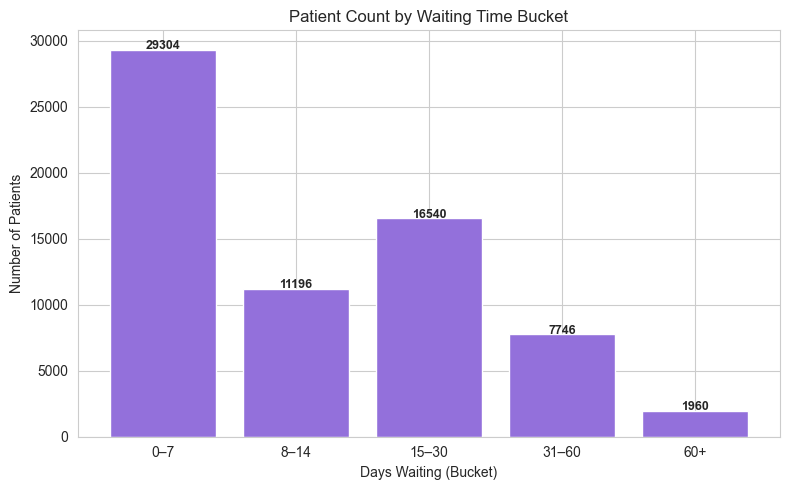

In [21]:
# 6.2 Waiting Time Bucket Analysis
df['wait_bucket'] = pd.cut(
    df['days_waiting'],
    bins=[0, 7, 14, 30, 60, 200],
    labels=['0–7', '8–14', '15–30', '31–60', '60+']
)

wait_counts = df['wait_bucket'].value_counts().sort_index()

plt.figure(figsize=(8, 5))
plt.bar(wait_counts.index, wait_counts.values, color='mediumpurple', edgecolor='white')
plt.title('Patient Count by Waiting Time Bucket')
plt.xlabel('Days Waiting (Bucket)')
plt.ylabel('Number of Patients')
for i, v in enumerate(wait_counts.values):
    plt.text(i, v + 50, str(v), ha='center', fontweight='bold', fontsize=9)
plt.tight_layout()
plt.show()

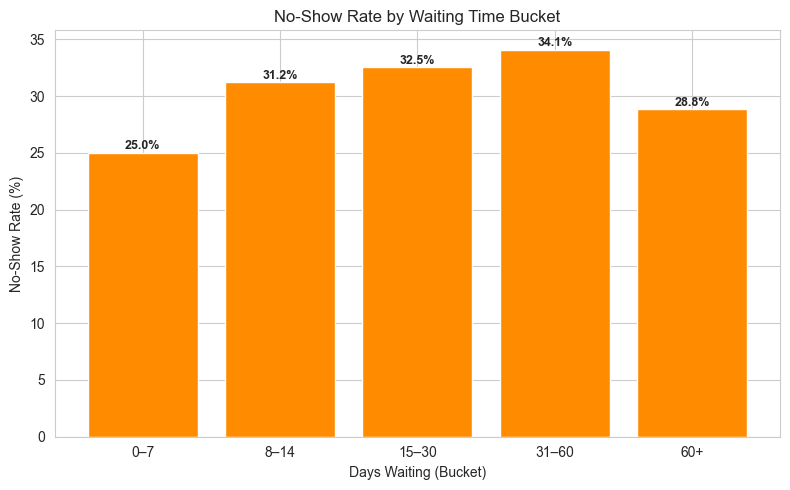

In [22]:
# 6.3 No-Show Rate by Waiting Time Bucket
wait_noshow = df.groupby('wait_bucket', observed=True)['no_show'].mean() * 100

plt.figure(figsize=(8, 5))
bars = plt.bar(wait_noshow.index, wait_noshow.values, color='darkorange', edgecolor='white')
plt.title('No-Show Rate by Waiting Time Bucket')
plt.xlabel('Days Waiting (Bucket)')
plt.ylabel('No-Show Rate (%)')
for i, v in enumerate(wait_noshow.values):
    plt.text(i, v + 0.3, f'{v:.1f}%', ha='center', fontweight='bold', fontsize=9)
plt.tight_layout()
plt.show()

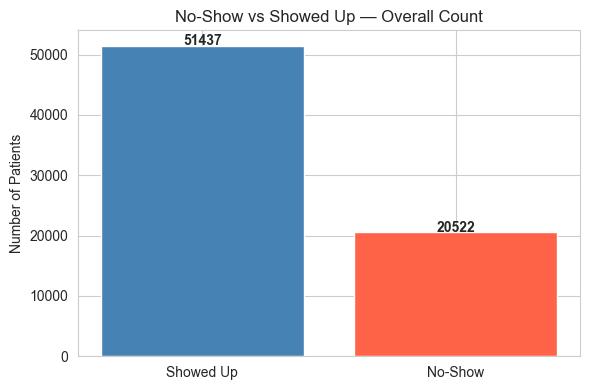

In [27]:
# 7.1 No-Show vs Showed Up Count
temp = df['no_show'].value_counts()
plt.figure(figsize=(6, 4))
plt.bar(['Showed Up', 'No-Show'], temp.values, color=['steelblue', 'tomato'], edgecolor='white')
plt.title("No-Show vs Showed Up — Overall Count")
plt.ylabel("Number of Patients")
for i, v in enumerate(temp.values):
    plt.text(i, v + 100, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

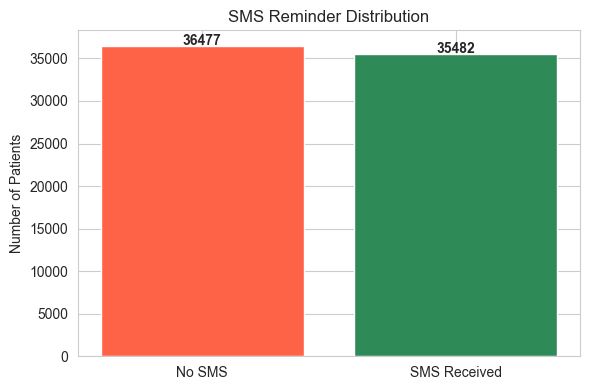

In [28]:
# 7.2 SMS Received Distribution
temp = df['sms_received'].value_counts()
plt.figure(figsize=(6, 4))
plt.bar(['No SMS', 'SMS Received'], temp.values, color=['tomato', 'seagreen'], edgecolor='white')
plt.title("SMS Reminder Distribution")
plt.ylabel("Number of Patients")
for i, v in enumerate(temp.values):
    plt.text(i, v + 100, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

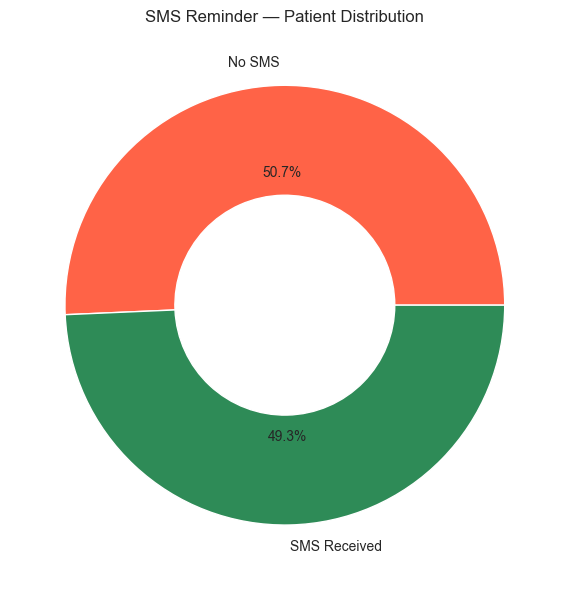

In [30]:
# 7.3 SMS Received — Pie Chart
temp = df['sms_received'].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(temp.values, labels=['No SMS', 'SMS Received'],
        colors=['tomato', 'seagreen'], autopct='%1.1f%%',
        wedgeprops={'width': 0.5})
plt.title("SMS Reminder — Patient Distribution")
plt.tight_layout()
plt.show()

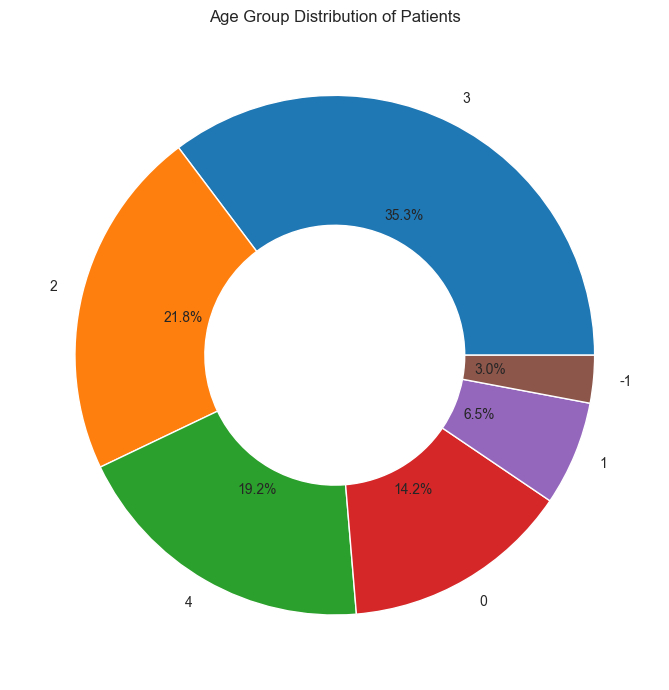

In [31]:
# 7.4 Age Group Distribution — Pie Chart
temp = df['age_group'].value_counts()
plt.figure(figsize=(7, 7))
plt.pie(temp.values, labels=temp.index, autopct='%1.1f%%',
        wedgeprops={'width': 0.5})
plt.title("Age Group Distribution of Patients")
plt.tight_layout()
plt.show()

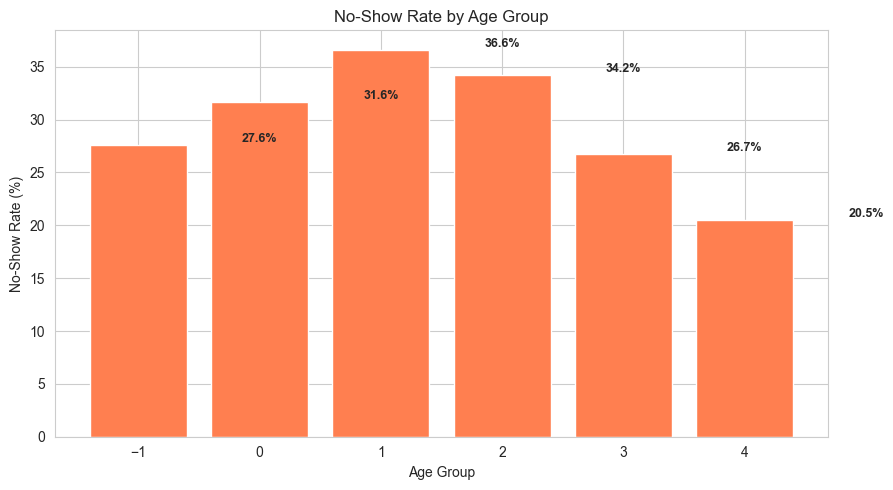

In [32]:
# 7.4.1 Age Group vs No-Show Rate
age_noshow = df.groupby('age_group')['no_show'].mean() * 100
plt.figure(figsize=(9, 5))
plt.bar(age_noshow.index, age_noshow.values, color='coral', edgecolor='white')
plt.title("No-Show Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("No-Show Rate (%)")
for i, v in enumerate(age_noshow.values):
    plt.text(i, v + 0.3, f'{v:.1f}%', ha='center', fontweight='bold', fontsize=9)
plt.tight_layout()
plt.show()

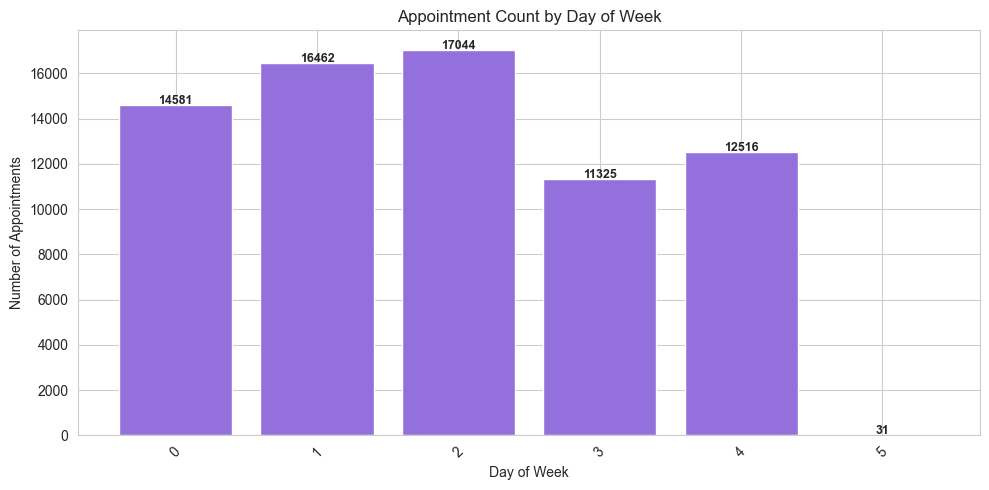

In [33]:
# 7.5 Appointment Count by Day of Week
temp = df['appointment_weekday'].value_counts().sort_index()
plt.figure(figsize=(10, 5))
plt.bar(temp.index, temp.values, color='mediumpurple', edgecolor='white')
plt.title("Appointment Count by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Number of Appointments")
plt.xticks(rotation=45)
for i, v in enumerate(temp.values):
    plt.text(i, v + 50, str(v), ha='center', fontweight='bold', fontsize=9)
plt.tight_layout()
plt.show()

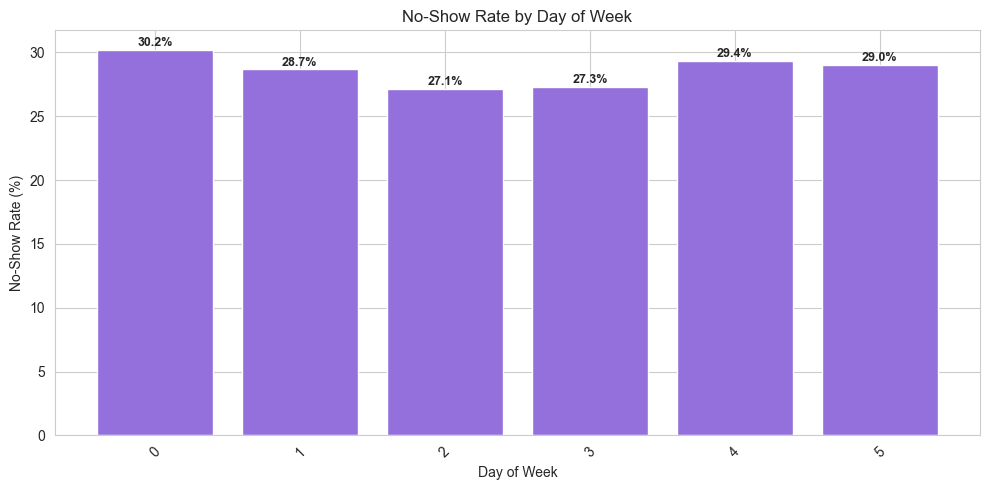

In [34]:
# 7.5.1 No-Show Rate by Day of Week
day_noshow = df.groupby('appointment_weekday')['no_show'].mean() * 100
plt.figure(figsize=(10, 5))
plt.bar(day_noshow.index, day_noshow.values, color='mediumpurple', edgecolor='white')
plt.title("No-Show Rate by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("No-Show Rate (%)")
plt.xticks(rotation=45)
for i, v in enumerate(day_noshow.values):
    plt.text(i, v + 0.3, f'{v:.1f}%', ha='center', fontweight='bold', fontsize=9)
plt.tight_layout()
plt.show()

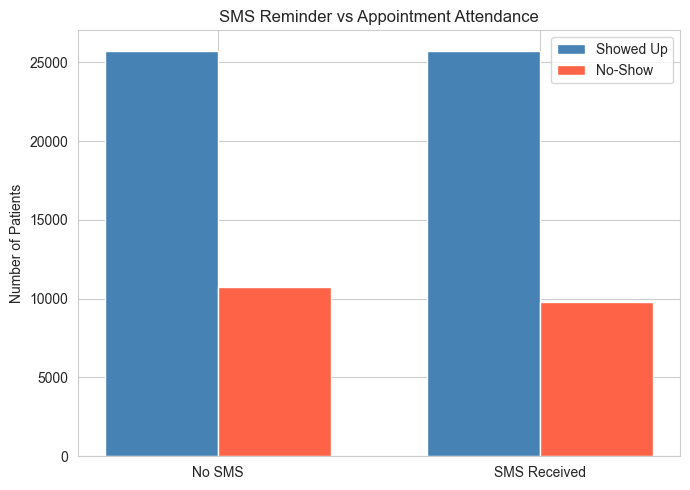

In [35]:
# 7.6 SMS Impact — Grouped Bar (Showed Up vs No-Show)
sms_groups = df.groupby('sms_received')['no_show'].value_counts().unstack()
sms_groups.index = ['No SMS', 'SMS Received']
sms_groups.columns = ['Showed Up', 'No-Show']

x = np.arange(len(sms_groups.index))
width = 0.35
plt.figure(figsize=(7, 5))
plt.bar(x - width/2, sms_groups['Showed Up'], width, label='Showed Up', color='steelblue')
plt.bar(x + width/2, sms_groups['No-Show'],   width, label='No-Show',   color='tomato')
plt.xticks(x, sms_groups.index)
plt.title("SMS Reminder vs Appointment Attendance")
plt.ylabel("Number of Patients")
plt.legend()
plt.tight_layout()
plt.show()

DAYS_WAITING ANOMALY ANALYSIS
Total Records        : 71,959
Anomalous Records    : 0
Anomaly Percentage   : 0.00%


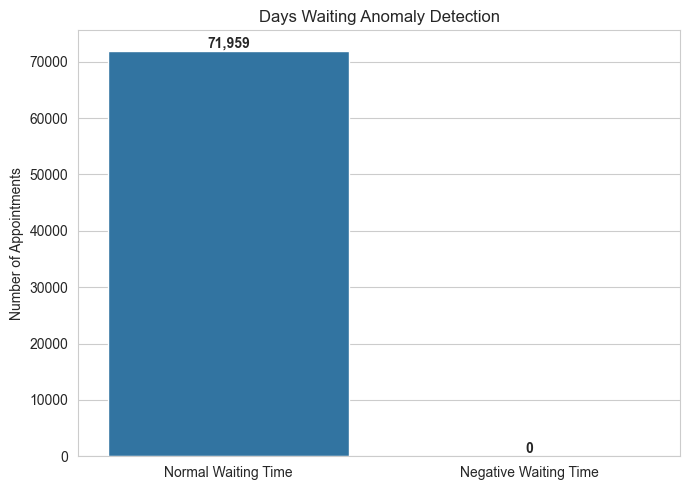

In [36]:
# ==========================================
# 8.1 Anomaly Detection Analysis
# ==========================================

# Detect anomalous waiting times
anomaly_count = (df['days_waiting'] < 0).sum()

# Percentage of anomalies
anomaly_percent = (anomaly_count / len(df)) * 100

print("=" * 50)
print("DAYS_WAITING ANOMALY ANALYSIS")
print("=" * 50)
print(f"Total Records        : {len(df):,}")
print(f"Anomalous Records    : {anomaly_count:,}")
print(f"Anomaly Percentage   : {anomaly_percent:.2f}%")

# Visualize anomaly vs normal records
anomaly_df = pd.DataFrame({
    'Category': ['Normal Waiting Time', 'Negative Waiting Time'],
    'Count': [
        (df['days_waiting'] >= 0).sum(),
        anomaly_count
    ]
})

plt.figure(figsize=(7, 5))

sns.barplot(
    data=anomaly_df,
    x='Category',
    y='Count'
)

plt.title("Days Waiting Anomaly Detection")
plt.xlabel("")
plt.ylabel("Number of Appointments")

for i, value in enumerate(anomaly_df['Count']):
    plt.text(i, value, f"{value:,}",
             ha='center',
             va='bottom',
             fontweight='bold')

plt.tight_layout()
plt.show()

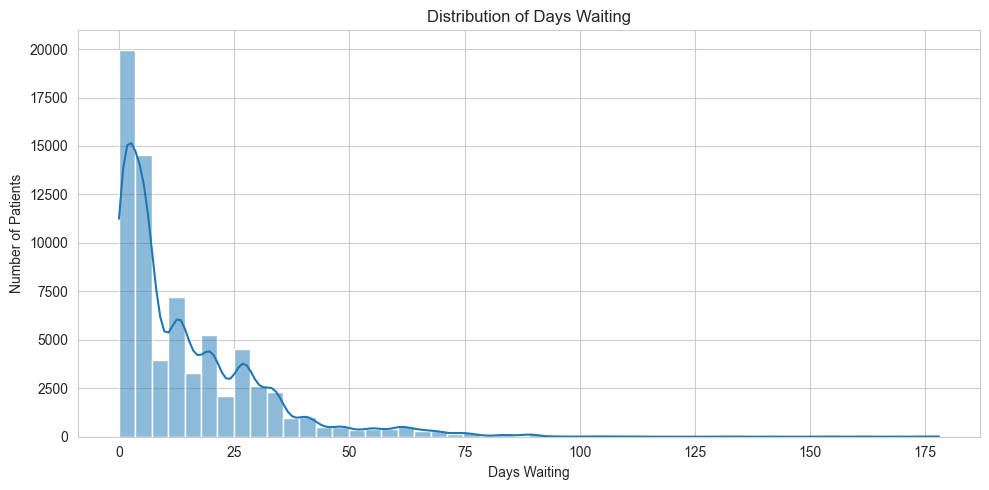

count    71959.000000
mean        14.642018
std         16.494334
min          0.000000
25%          3.000000
50%          8.000000
75%         21.000000
max        178.000000
Name: days_waiting, dtype: float64


In [37]:
# ==========================================
# 8.2 Distribution of Days Waiting
# ==========================================

plt.figure(figsize=(10, 5))

sns.histplot(
    df['days_waiting'],
    bins=50,
    kde=True
)

plt.title("Distribution of Days Waiting")
plt.xlabel("Days Waiting")
plt.ylabel("Number of Patients")

plt.tight_layout()
plt.show()

# Summary statistics
print(df['days_waiting'].describe())

       waiting_anomaly    no_show
0  Normal Waiting Time  28.519018


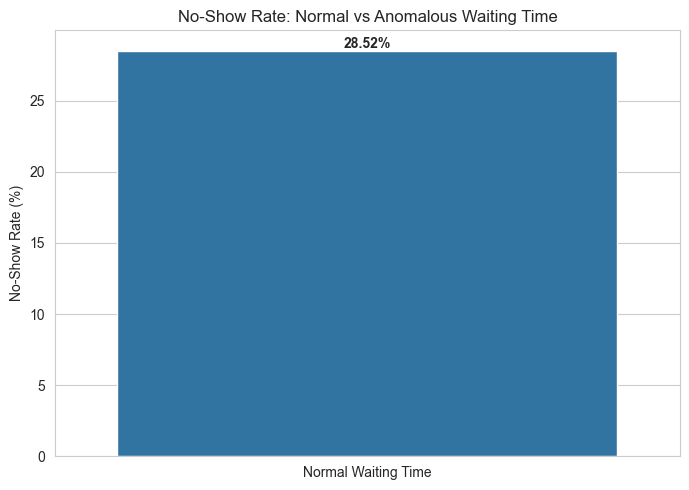

In [38]:
# ==========================================
# 8.3 Impact of Waiting Time Anomalies on No-Show
# ==========================================

# Create anomaly flag
df['waiting_anomaly'] = df['days_waiting'] < 0

# Calculate no-show rate
anomaly_target = (
    df.groupby('waiting_anomaly')['no_show']
      .mean()
      .mul(100)
      .reset_index()
)

anomaly_target['waiting_anomaly'] = anomaly_target['waiting_anomaly'].map({
    False: 'Normal Waiting Time',
    True: 'Negative Waiting Time'
})

print(anomaly_target)

# Visualization
plt.figure(figsize=(7, 5))

ax = sns.barplot(
    data=anomaly_target,
    x='waiting_anomaly',
    y='no_show'
)

plt.title("No-Show Rate: Normal vs Anomalous Waiting Time")
plt.xlabel("")
plt.ylabel("No-Show Rate (%)")

for p in ax.patches:
    ax.annotate(
        f'{p.get_height():.2f}%',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom',
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

                     age  days_waiting  scheduled_hour   no_show
age             1.000000     -0.008608       -0.020653 -0.101042
days_waiting   -0.008608      1.000000        0.030068  0.060362
scheduled_hour -0.020653      0.030068        1.000000  0.030742
no_show        -0.101042      0.060362        0.030742  1.000000


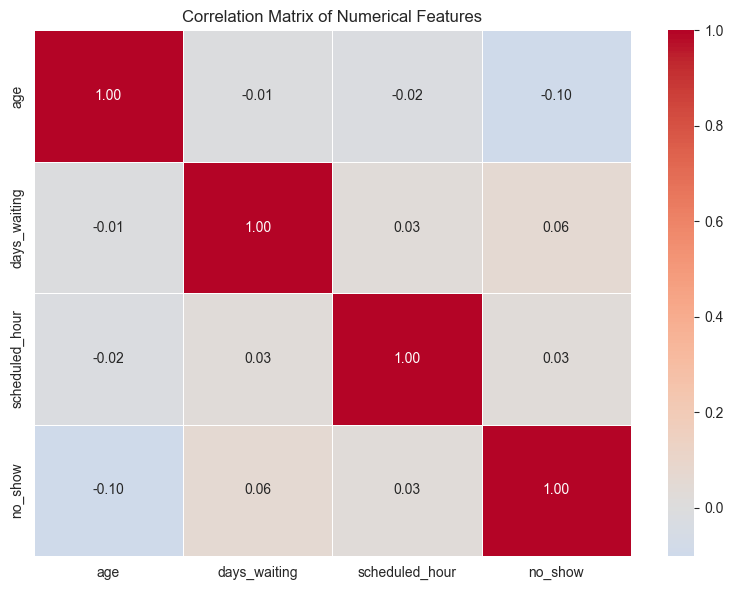

In [39]:
# ==========================================
# 8.4 Correlation Analysis
# ==========================================

# Select numerical columns
numerical_cols = [
    'age',
    'days_waiting',
    'scheduled_hour',
    'no_show'
]

corr_matrix = df[numerical_cols].corr()

# Display correlation matrix
print(corr_matrix)

# Heatmap
plt.figure(figsize=(8, 6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    center=0,
    fmt='.2f',
    linewidths=0.5
)

plt.title("Correlation Matrix of Numerical Features")
plt.tight_layout()
plt.show()

Correlation with No-Show:
age              -0.101042
scheduled_hour    0.030742
days_waiting      0.060362
Name: no_show, dtype: float64


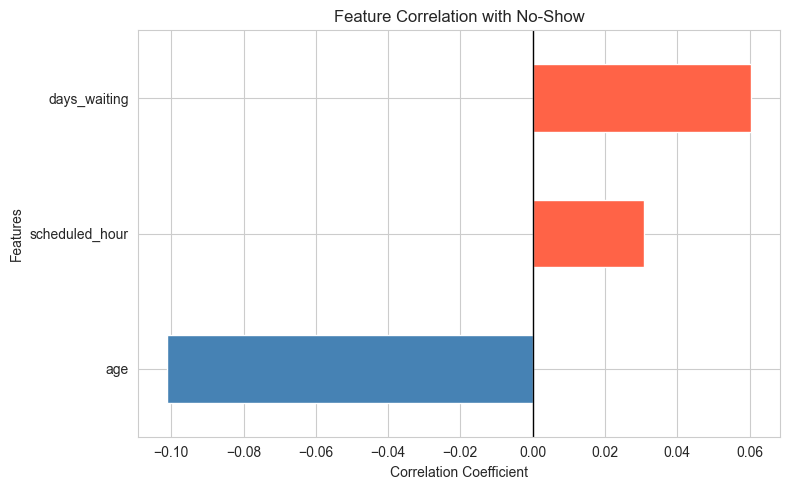

In [40]:
# ==========================================
# 8.5 Feature Correlation with No-Show
# ==========================================

# Select numerical features
numerical_cols = [
    'age',
    'days_waiting',
    'scheduled_hour',
    'no_show'
]

# Correlation with target
target_corr = (
    df[numerical_cols]
    .corr()['no_show']
    .drop('no_show')
    .sort_values()
)

print("Correlation with No-Show:")
print(target_corr)

# Visualization
plt.figure(figsize=(8, 5))

colors = ['tomato' if x > 0 else 'steelblue' for x in target_corr.values]

target_corr.plot(
    kind='barh',
    color=colors
)

plt.title("Feature Correlation with No-Show")
plt.xlabel("Correlation Coefficient")
plt.ylabel("Features")
plt.axvline(0, color='black', linewidth=1)

plt.tight_layout()
plt.show()

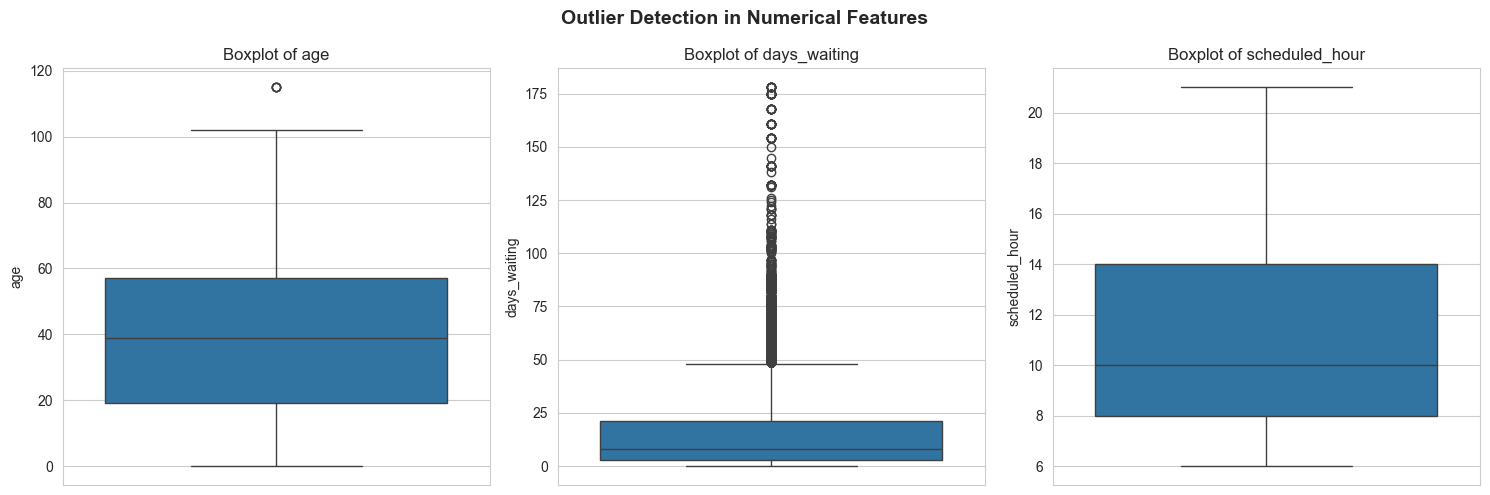

In [41]:
# ==========================================
# 9.1 Outlier Detection Using Boxplots
# ==========================================

numerical_features = [
    'age',
    'days_waiting',
    'scheduled_hour'
]

fig, axes = plt.subplots(1, len(numerical_features), figsize=(15, 5))

for i, col in enumerate(numerical_features):
    sns.boxplot(
        y=df[col],
        ax=axes[i]
    )

    axes[i].set_title(f'Boxplot of {col}')
    axes[i].set_ylabel(col)

plt.suptitle(
    "Outlier Detection in Numerical Features",
    fontsize=14,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

          Feature  Outlier Count  Outlier Percentage
0             age              4                0.01
1    days_waiting           3310                4.60
2  scheduled_hour              0                0.00


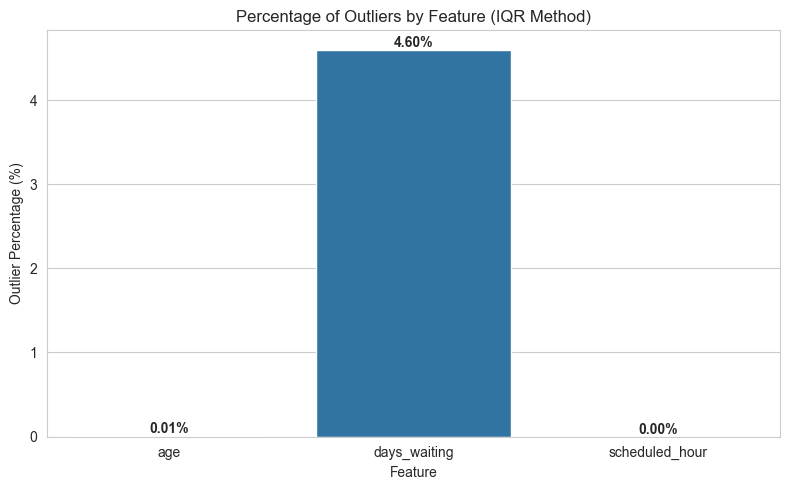

In [42]:
# ==========================================
# 9.2 Quantifying Outliers Using IQR
# ==========================================

numerical_features = [
    'age',
    'days_waiting',
    'scheduled_hour'
]

outlier_summary = []

for col in numerical_features:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - (1.5 * IQR)
    upper_bound = Q3 + (1.5 * IQR)

    outliers = df[
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    ]

    outlier_summary.append({
        'Feature': col,
        'Outlier Count': len(outliers),
        'Outlier Percentage': round((len(outliers) / len(df)) * 100, 2)
    })

outlier_df = pd.DataFrame(outlier_summary)

print(outlier_df)

# Visualization
plt.figure(figsize=(8, 5))

sns.barplot(
    data=outlier_df,
    x='Feature',
    y='Outlier Percentage'
)

plt.title("Percentage of Outliers by Feature (IQR Method)")
plt.ylabel("Outlier Percentage (%)")
plt.xlabel("Feature")

for i, value in enumerate(outlier_df['Outlier Percentage']):
    plt.text(
        i,
        value,
        f'{value:.2f}%',
        ha='center',
        va='bottom',
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

        waiting_outlier    no_show
0   Normal Waiting Time  28.440327
1  Waiting Time Outlier  30.151057


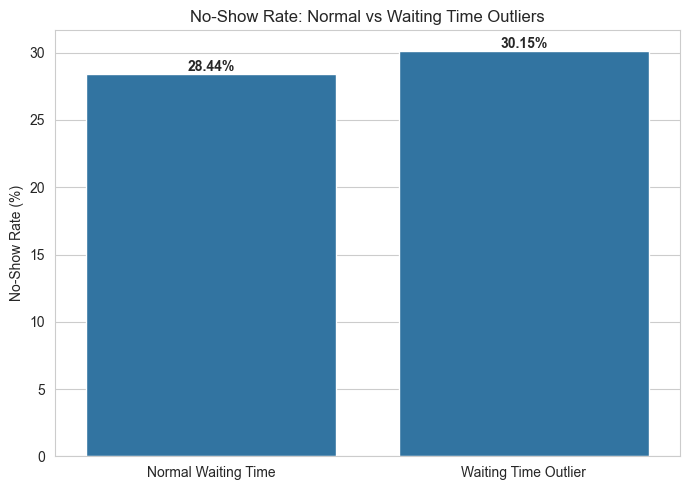

In [43]:
# ==========================================
# 9.3 Outlier Impact on No-Show Rate
# ==========================================

# IQR calculation for days_waiting
Q1 = df['days_waiting'].quantile(0.25)
Q3 = df['days_waiting'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - (1.5 * IQR)
upper_bound = Q3 + (1.5 * IQR)

# Create outlier flag
df['waiting_outlier'] = (
    (df['days_waiting'] < lower_bound) |
    (df['days_waiting'] > upper_bound)
)

# Compare no-show rates
outlier_impact = (
    df.groupby('waiting_outlier')['no_show']
      .mean()
      .mul(100)
      .reset_index()
)

outlier_impact['waiting_outlier'] = outlier_impact['waiting_outlier'].map({
    False: 'Normal Waiting Time',
    True: 'Waiting Time Outlier'
})

print(outlier_impact)

# Visualization
plt.figure(figsize=(7, 5))

ax = sns.barplot(
    data=outlier_impact,
    x='waiting_outlier',
    y='no_show'
)

plt.title("No-Show Rate: Normal vs Waiting Time Outliers")
plt.xlabel("")
plt.ylabel("No-Show Rate (%)")

for p in ax.patches:
    ax.annotate(
        f'{p.get_height():.2f}%',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom',
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

Target Distribution:
no_show
0    51437
1    20522
Name: count, dtype: int64

Target Percentage:
no_show
0    71.480982
1    28.519018
Name: proportion, dtype: float64


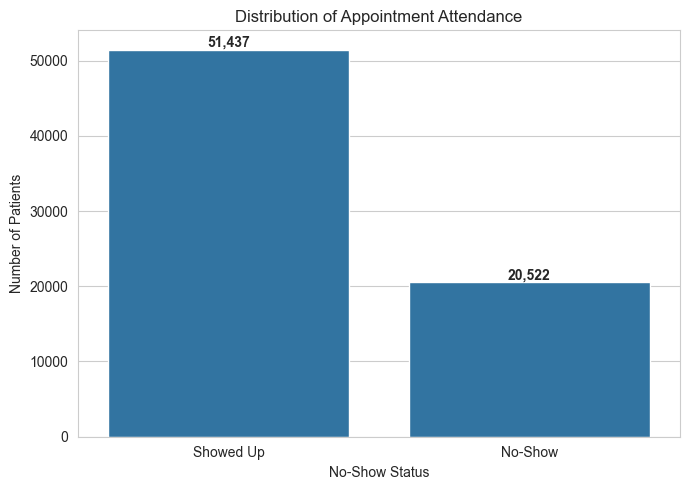

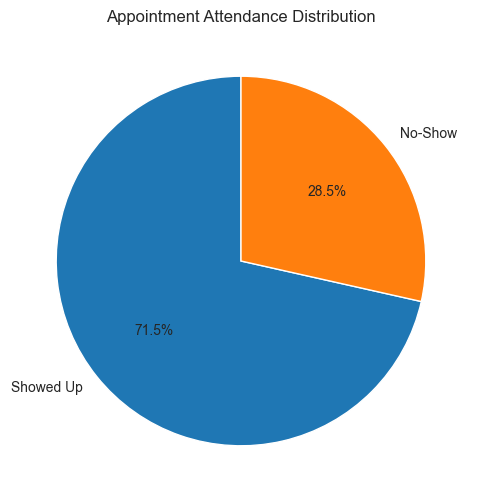

In [44]:
# ==========================================
# 10.1 Target Variable Distribution
# ==========================================

target_counts = df['no_show'].value_counts().sort_index()

print("Target Distribution:")
print(target_counts)

# Percentage distribution
target_percent = (
    df['no_show']
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

print("\nTarget Percentage:")
print(target_percent)

# Visualization
plt.figure(figsize=(7, 5))

ax = sns.countplot(
    data=df,
    x='no_show'
)

plt.title("Distribution of Appointment Attendance")
plt.xlabel("No-Show Status")
plt.ylabel("Number of Patients")

plt.xticks(
    [0, 1],
    ['Showed Up', 'No-Show']
)

for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height()):,}',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom',
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

# Pie Chart
plt.figure(figsize=(6, 6))

plt.pie(
    target_counts.values,
    labels=['Showed Up', 'No-Show'],
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Appointment Attendance Distribution")
plt.show()

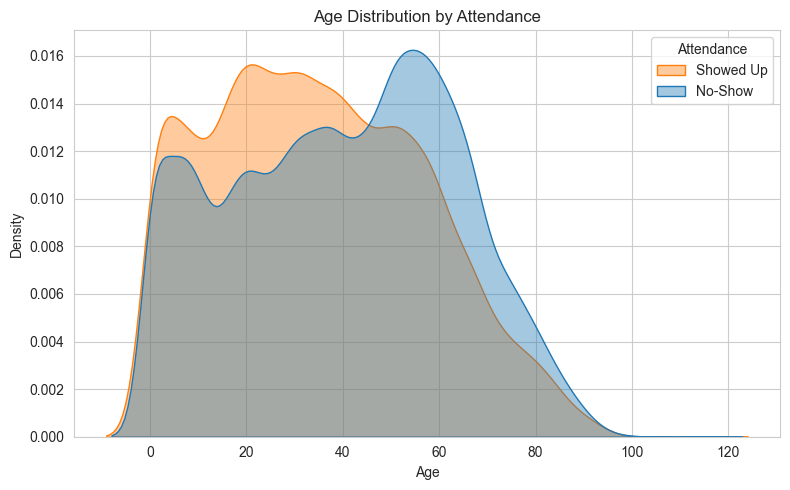


AGE SUMMARY
              mean        std  min   25%   50%   75%    max
no_show                                                    
0        39.965706  23.140047  0.0  21.0  41.0  58.0  115.0
1        34.835299  21.954582  0.0  17.0  33.0  51.0  115.0


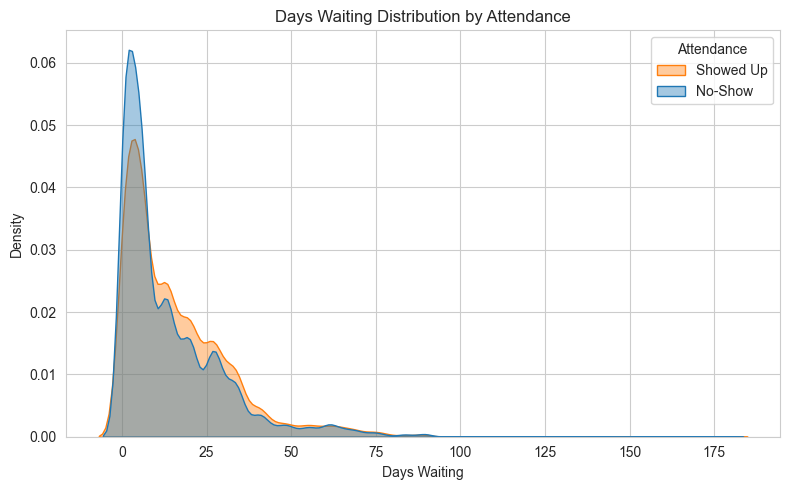


DAYS_WAITING SUMMARY
              mean        std  min  25%   50%   75%    max
no_show                                                   
0        14.013142  16.404411  0.0  3.0   7.0  20.0  178.0
1        16.218254  16.613713  0.0  4.0  12.0  24.0  178.0


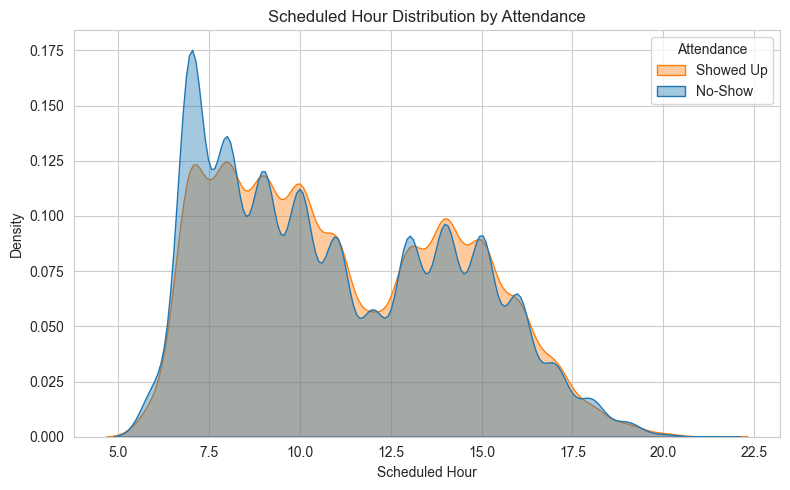


SCHEDULED_HOUR SUMMARY
              mean       std  min  25%   50%   75%   max
no_show                                                 
0        11.013162  3.297531  6.0  8.0  10.0  14.0  21.0
1        11.236283  3.219344  6.0  8.0  11.0  14.0  21.0


In [45]:
# ==========================================
# 10.2 Numerical Features vs Target
# ==========================================

numerical_features = [
    'age',
    'days_waiting',
    'scheduled_hour'
]

for feature in numerical_features:

    plt.figure(figsize=(8, 5))

    sns.kdeplot(
        data=df,
        x=feature,
        hue='no_show',
        fill=True,
        common_norm=False,
        alpha=0.4
    )

    plt.title(f"{feature.replace('_', ' ').title()} Distribution by Attendance")
    plt.xlabel(feature.replace('_', ' ').title())
    plt.ylabel("Density")

    plt.legend(
        labels=['Showed Up', 'No-Show'],
        title='Attendance'
    )

    plt.tight_layout()
    plt.show()

    # Summary statistics
    print(f"\n{'='*50}")
    print(f"{feature.upper()} SUMMARY")
    print(f"{'='*50}")

    print(
        df.groupby('no_show')[feature]
          .describe()[['mean', 'std', 'min', '25%', '50%', '75%', 'max']]
    )

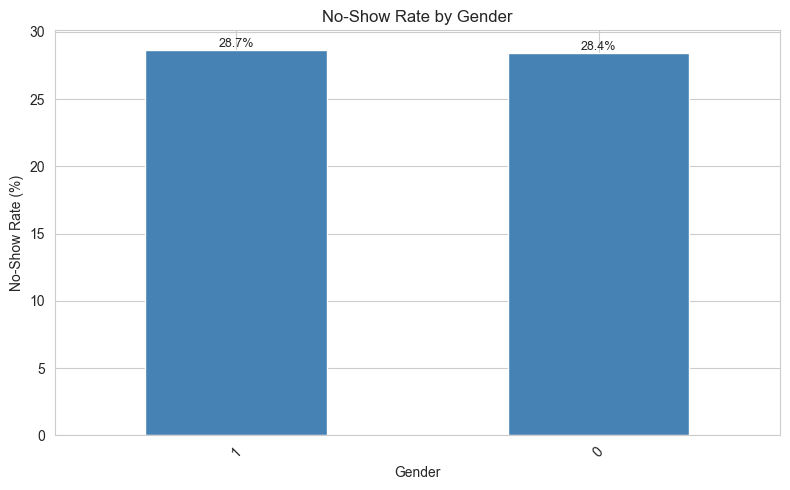

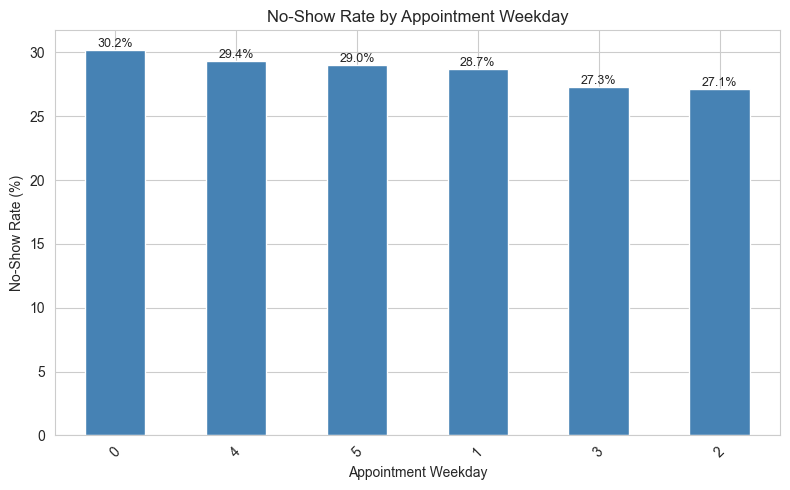

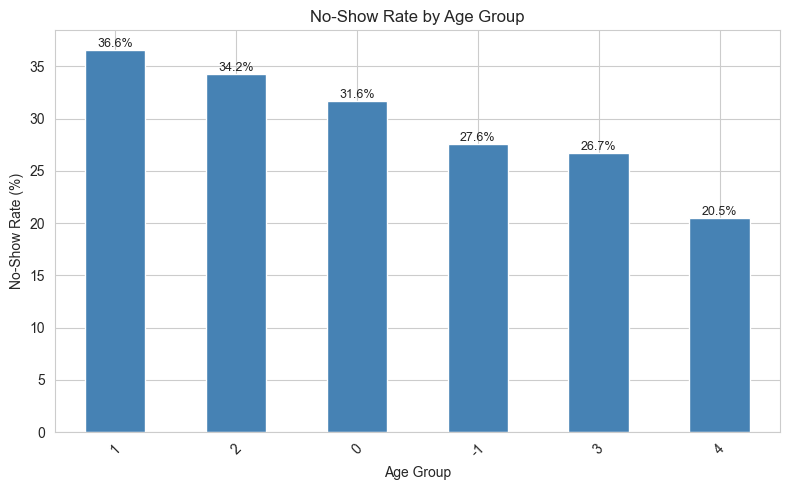

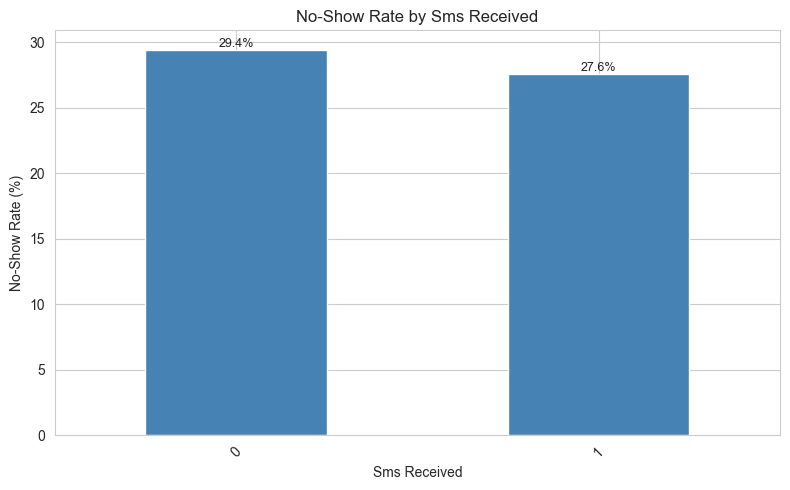

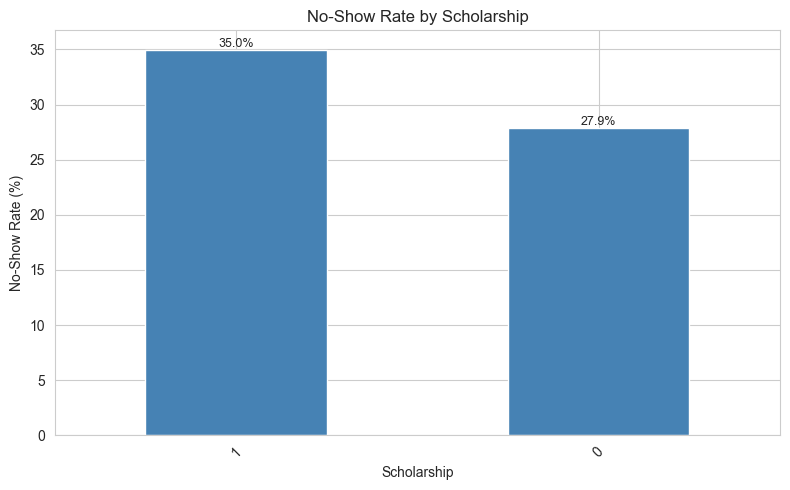

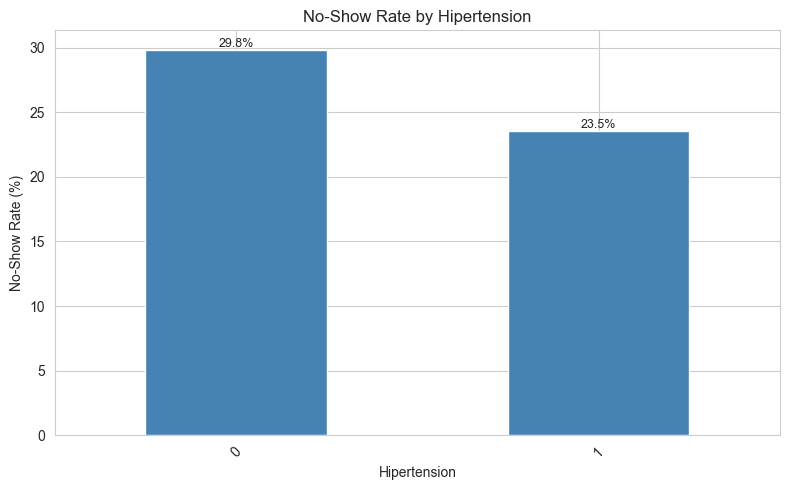

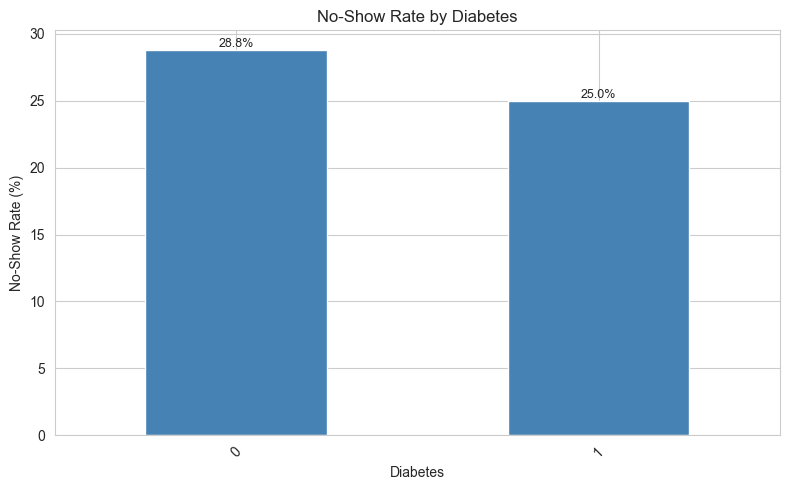

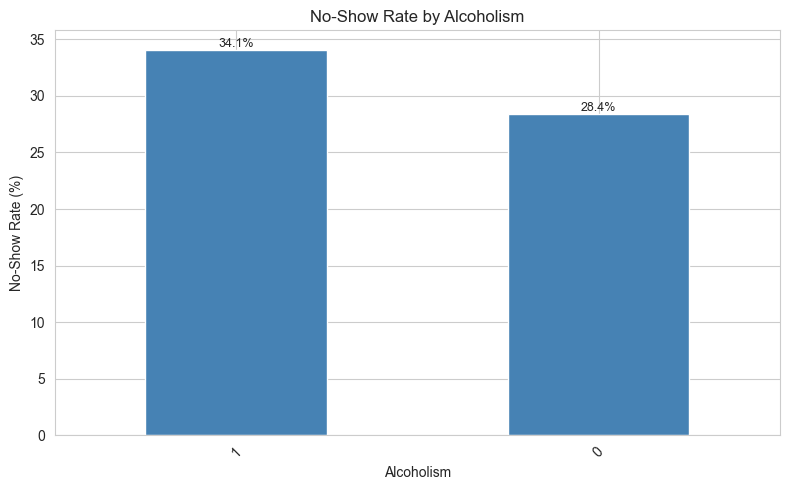

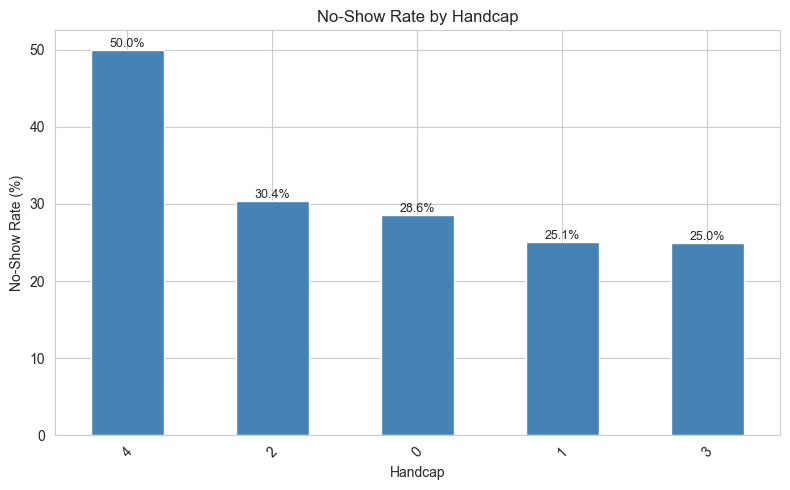

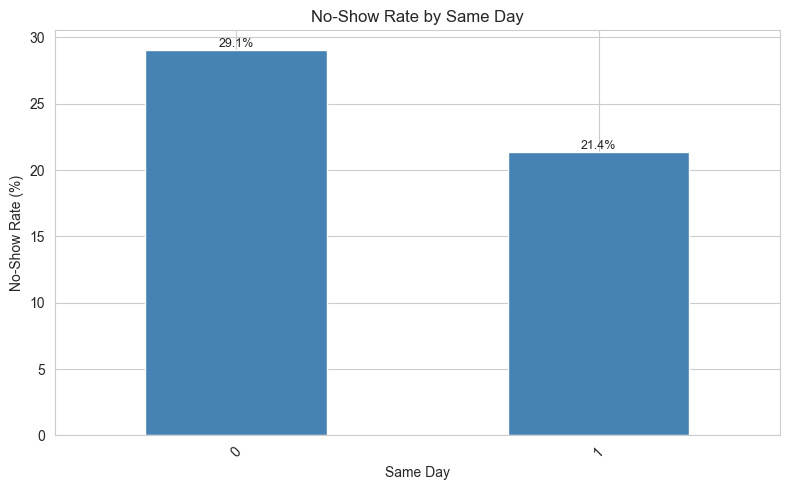

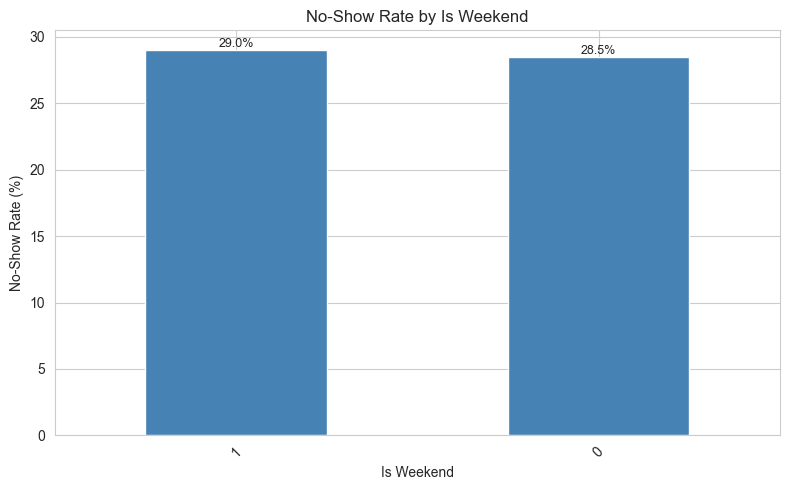

In [46]:
# ==========================================
# 10.3 Categorical Features vs Target
# ==========================================

categorical_features = [
    'gender',
    'appointment_weekday',
    'age_group',
    'sms_received',
    'scholarship',
    'hipertension',
    'diabetes',
    'alcoholism',
    'handcap',
    'same_day',
    'is_weekend'
]

for feature in categorical_features:

    plt.figure(figsize=(8, 5))

    target_rate = (
        df.groupby(feature)['no_show']
          .mean()
          .mul(100)
          .sort_values(ascending=False)
    )

    ax = target_rate.plot(
        kind='bar',
        color='steelblue'
    )

    plt.title(f'No-Show Rate by {feature.replace("_", " ").title()}')
    plt.xlabel(feature.replace("_", " ").title())
    plt.ylabel('No-Show Rate (%)')
    plt.xticks(rotation=45)

    for p in ax.patches:
        ax.annotate(
            f'{p.get_height():.1f}%',
            (p.get_x() + p.get_width()/2, p.get_height()),
            ha='center',
            va='bottom',
            fontsize=9
        )

    plt.tight_layout()
    plt.show()


AGE VS NO_SHOW
           count   mean  median    std  min  max
Showed Up  51437  39.97    41.0  23.14    0  115
No-Show    20522  34.84    33.0  21.95    0  115


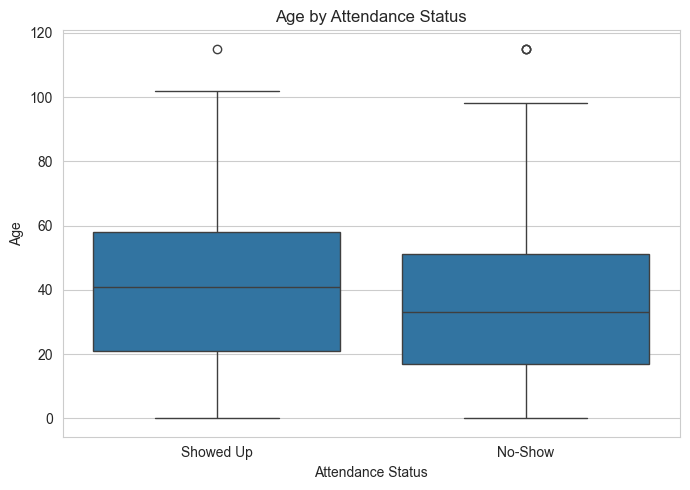


DAYS_WAITING VS NO_SHOW
           count   mean  median    std  min  max
Showed Up  51437  14.01     7.0  16.40    0  178
No-Show    20522  16.22    12.0  16.61    0  178


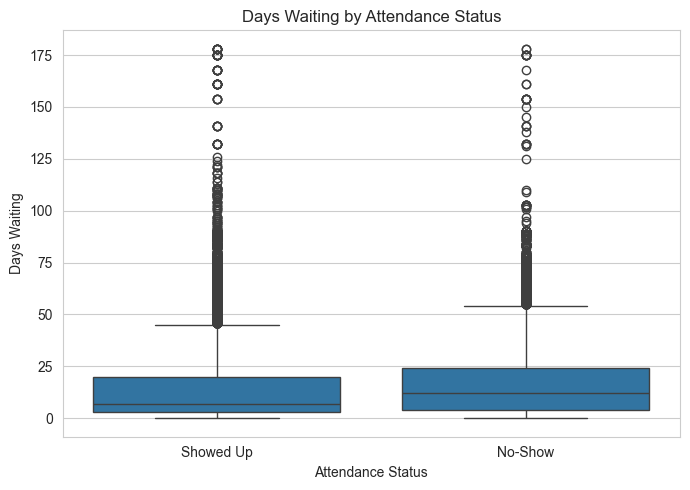


SCHEDULED_HOUR VS NO_SHOW
           count   mean  median   std  min  max
Showed Up  51437  11.01    10.0  3.30    6   21
No-Show    20522  11.24    11.0  3.22    6   21


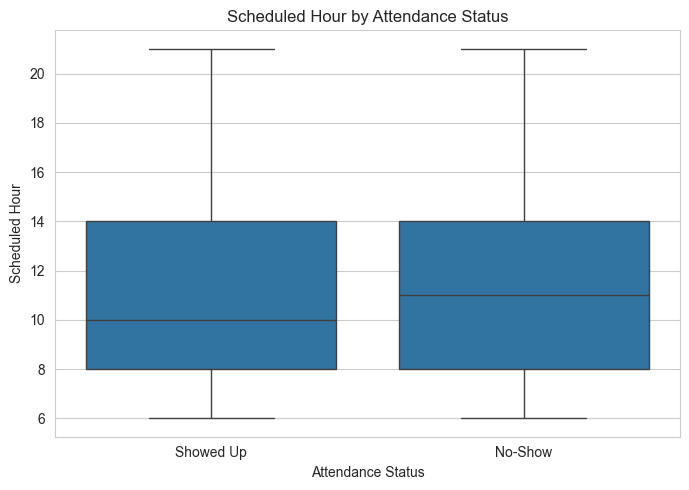

In [47]:
# ==========================================
# 10.4 Numerical Features by Target Statistics
# ==========================================

numerical_features = [
    'age',
    'days_waiting',
    'scheduled_hour'
]

for feature in numerical_features:

    print("\n" + "="*70)
    print(f"{feature.upper()} VS NO_SHOW")
    print("="*70)

    stats = (
        df.groupby('no_show')[feature]
          .agg([
              'count',
              'mean',
              'median',
              'std',
              'min',
              'max'
          ])
          .round(2)
    )

    stats.index = ['Showed Up', 'No-Show']

    print(stats)

    # Visualization
    plt.figure(figsize=(7, 5))

    sns.boxplot(
        data=df,
        x='no_show',
        y=feature
    )

    plt.xticks(
        [0, 1],
        ['Showed Up', 'No-Show']
    )

    plt.title(f'{feature.replace("_", " ").title()} by Attendance Status')
    plt.xlabel('Attendance Status')
    plt.ylabel(feature.replace("_", " ").title())

    plt.tight_layout()
    plt.show()

Numerical Feature Importance (Absolute Correlation)
age               0.101042
days_waiting      0.060362
scheduled_hour    0.030742
Name: no_show, dtype: float64


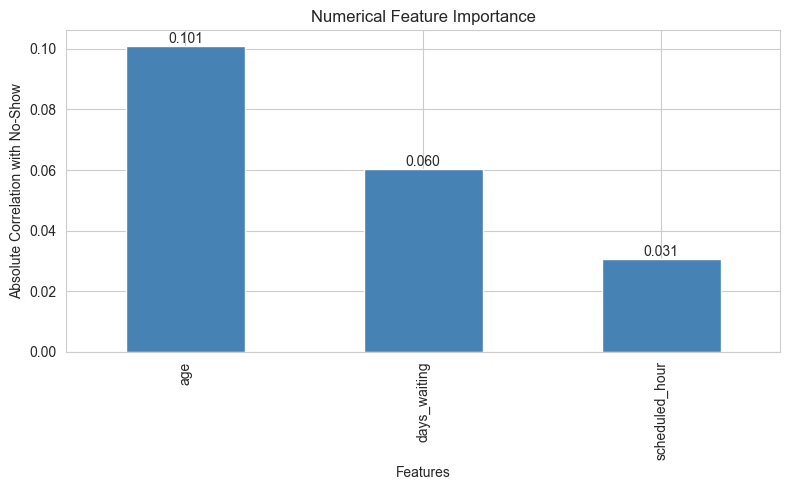


Categorical Feature Impact Ranking
                Feature  Impact Score
8               handcap     25.000000
2             age_group     16.146026
9              same_day      7.728426
4           scholarship      7.112631
5          hipertension      6.315063
7            alcoholism      5.708958
6              diabetes      3.848429
1   appointment_weekday      3.063165
3          sms_received      1.863183
10           is_weekend      0.513461
0                gender      0.219897


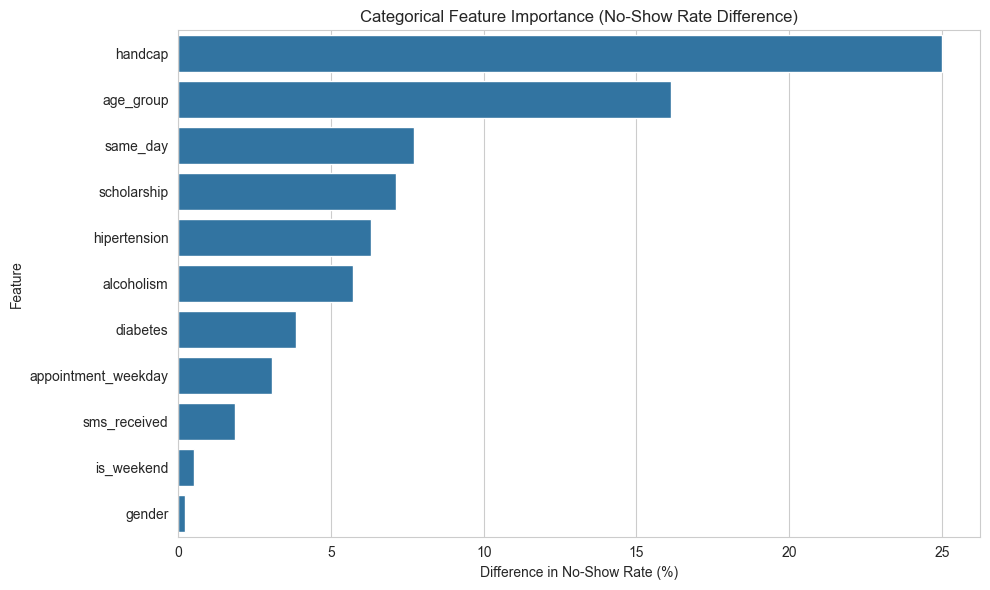

In [48]:
# ==========================================
# 11.1 Feature Importance Analysis
# ==========================================

# Numerical correlations with target
numerical_features = [
    'age',
    'days_waiting',
    'scheduled_hour'
]

corr_importance = (
    df[numerical_features + ['no_show']]
    .corr()['no_show']
    .drop('no_show')
    .abs()
    .sort_values(ascending=False)
)

print("Numerical Feature Importance (Absolute Correlation)")
print(corr_importance)

# Visualization
plt.figure(figsize=(8, 5))

ax = corr_importance.plot(
    kind='bar',
    color='steelblue'
)

plt.title("Numerical Feature Importance")
plt.xlabel("Features")
plt.ylabel("Absolute Correlation with No-Show")

for p in ax.patches:
    ax.annotate(
        f'{p.get_height():.3f}',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()


# Categorical Feature Impact
categorical_features = [
    'gender',
    'appointment_weekday',
    'age_group',
    'sms_received',
    'scholarship',
    'hipertension',
    'diabetes',
    'alcoholism',
    'handcap',
    'same_day',
    'is_weekend'
]

importance_scores = []

for feature in categorical_features:

    rates = df.groupby(feature)['no_show'].mean() * 100

    importance_scores.append({
        'Feature': feature,
        'Impact Score': rates.max() - rates.min()
    })

importance_df = pd.DataFrame(importance_scores)
importance_df = importance_df.sort_values(
    by='Impact Score',
    ascending=False
)

print("\nCategorical Feature Impact Ranking")
print(importance_df)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=importance_df,
    x='Impact Score',
    y='Feature'
)

plt.title("Categorical Feature Importance (No-Show Rate Difference)")
plt.xlabel("Difference in No-Show Rate (%)")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

                Feature  Missing Values  Missing Percentage
18          wait_bucket            5213                7.24
1                   age               0                0.00
2         neighbourhood               0                0.00
3           scholarship               0                0.00
0                gender               0                0.00
4          hipertension               0                0.00
5              diabetes               0                0.00
7               handcap               0                0.00
6            alcoholism               0                0.00
9               no_show               0                0.00
10         days_waiting               0                0.00
11  appointment_weekday               0                0.00
8          sms_received               0                0.00
12       scheduled_hour               0                0.00
13             same_day               0                0.00
15           is_weekend               0 

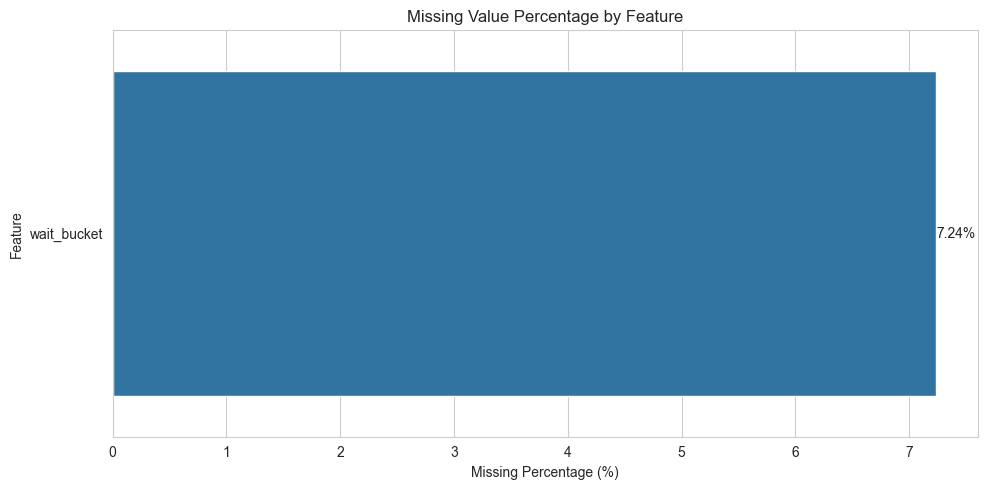

In [49]:
# ==========================================
# 11.2 Missing Value Analysis
# ==========================================

missing_values = df.isnull().sum()

missing_df = pd.DataFrame({
    'Feature': missing_values.index,
    'Missing Values': missing_values.values,
    'Missing Percentage': (
        missing_values.values / len(df) * 100
    ).round(2)
})

missing_df = missing_df.sort_values(
    by='Missing Percentage',
    ascending=False
)

print(missing_df)

# Keep only columns with missing values
missing_plot = missing_df[
    missing_df['Missing Values'] > 0
]

if len(missing_plot) > 0:

    plt.figure(figsize=(10, 5))

    ax = sns.barplot(
        data=missing_plot,
        x='Missing Percentage',
        y='Feature'
    )

    plt.title("Missing Value Percentage by Feature")
    plt.xlabel("Missing Percentage (%)")
    plt.ylabel("Feature")

    for p in ax.patches:
        ax.annotate(
            f'{p.get_width():.2f}%',
            (p.get_width(), p.get_y() + p.get_height()/2),
            va='center'
        )

    plt.tight_layout()
    plt.show()

else:
    print("✅ No missing values found in the dataset.")

In [50]:
# ==========================================
# 11.3 Final Dataset Summary
# ==========================================

print("=" * 80)
print("PATIENT NO-SHOW DATASET - FINAL EDA SUMMARY")
print("=" * 80)

print(f"\nDataset Shape: {df.shape}")
print(f"Total Features: {df.shape[1]}")
print(f"Total Records: {len(df):,}")

print("\n" + "=" * 80)
print("TARGET DISTRIBUTION")
print("=" * 80)

attendance_rate = (1 - df['no_show'].mean()) * 100
noshow_rate = df['no_show'].mean() * 100

print(f"Show-Up Rate : {attendance_rate:.2f}%")
print(f"No-Show Rate : {noshow_rate:.2f}%")

print("\n" + "=" * 80)
print("NUMERICAL FEATURES")
print("=" * 80)

numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

summary_stats = df[numerical_cols].describe().T

display(summary_stats)

print("\n" + "=" * 80)
print("DATA QUALITY CHECK")
print("=" * 80)

print(f"Missing Values : {df.isnull().sum().sum()}")
print(f"Duplicate Rows : {df.duplicated().sum()}")

print("\n" + "=" * 80)
print("TOP NO-SHOW FACTORS")
print("=" * 80)

# Waiting Time Impact
wait_effect = df.groupby('wait_bucket', observed=True)['no_show'].mean() * 100

print("\nNo-Show Rate by Waiting Time:")
print(wait_effect.sort_values(ascending=False))

# SMS Impact
sms_effect = df.groupby('sms_received')['no_show'].mean() * 100

print("\nNo-Show Rate by SMS Status:")
print(sms_effect)

# Age Group Impact
age_effect = df.groupby('age_group')['no_show'].mean() * 100

print("\nNo-Show Rate by Age Group:")
print(age_effect.sort_values(ascending=False))

print("\n" + "=" * 80)
print("EDA COMPLETED SUCCESSFULLY")
print("=" * 80)

PATIENT NO-SHOW DATASET - FINAL EDA SUMMARY

Dataset Shape: (71959, 21)
Total Features: 21
Total Records: 71,959

TARGET DISTRIBUTION
Show-Up Rate : 71.48%
No-Show Rate : 28.52%

NUMERICAL FEATURES


,count,mean,std,min,25%,50%,75%,max
gender,71959.0,0.331981,0.470927,0.000000,0.000000,0.0,1.000000,1.0
age,71959.0,38.502564,22.925421,0.000000,19.000000,39.0,57.000000,115.0
neighbourhood,71959.0,41.499632,22.292102,0.000000,25.000000,39.0,59.000000,80.0
scholarship,71959.0,0.092706,0.290021,0.000000,0.000000,0.0,0.000000,1.0
hipertension,71959.0,0.208897,0.406523,0.000000,0.000000,0.0,0.000000,1.0
diabetes,71959.0,0.074723,0.262946,0.000000,0.000000,0.0,0.000000,1.0
alcoholism,71959.0,0.025320,0.157096,0.000000,0.000000,0.0,0.000000,1.0
handcap,71959.0,0.020025,0.154072,0.000000,0.000000,0.0,0.000000,4.0
sms_received,71959.0,0.493086,0.499956,0.000000,0.000000,0.0,1.000000,1.0
no_show,71959.0,0.285190,0.451508,0.000000,0.000000,0.0,1.000000,1.0



DATA QUALITY CHECK
Missing Values : 5213
Duplicate Rows : 2305

TOP NO-SHOW FACTORS

No-Show Rate by Waiting Time:
wait_bucket
31–60    34.082107
15–30    32.521161
8–14     31.225438
60+      28.826531
0–7      25.010238
Name: no_show, dtype: float64

No-Show Rate by SMS Status:
sms_received
0    29.437728
1    27.574545
Name: no_show, dtype: float64

No-Show Rate by Age Group:
age_group
 1    36.608287
 2    34.225110
 0    31.647427
-1    27.592679
 3    26.710008
 4    20.462261
Name: no_show, dtype: float64

EDA COMPLETED SUCCESSFULLY
